In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

# Descision Tree

In [3]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Traning accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

Traning accuracy:  97.91332263242376 %
Testing accuracy:  75.74626865671642 %


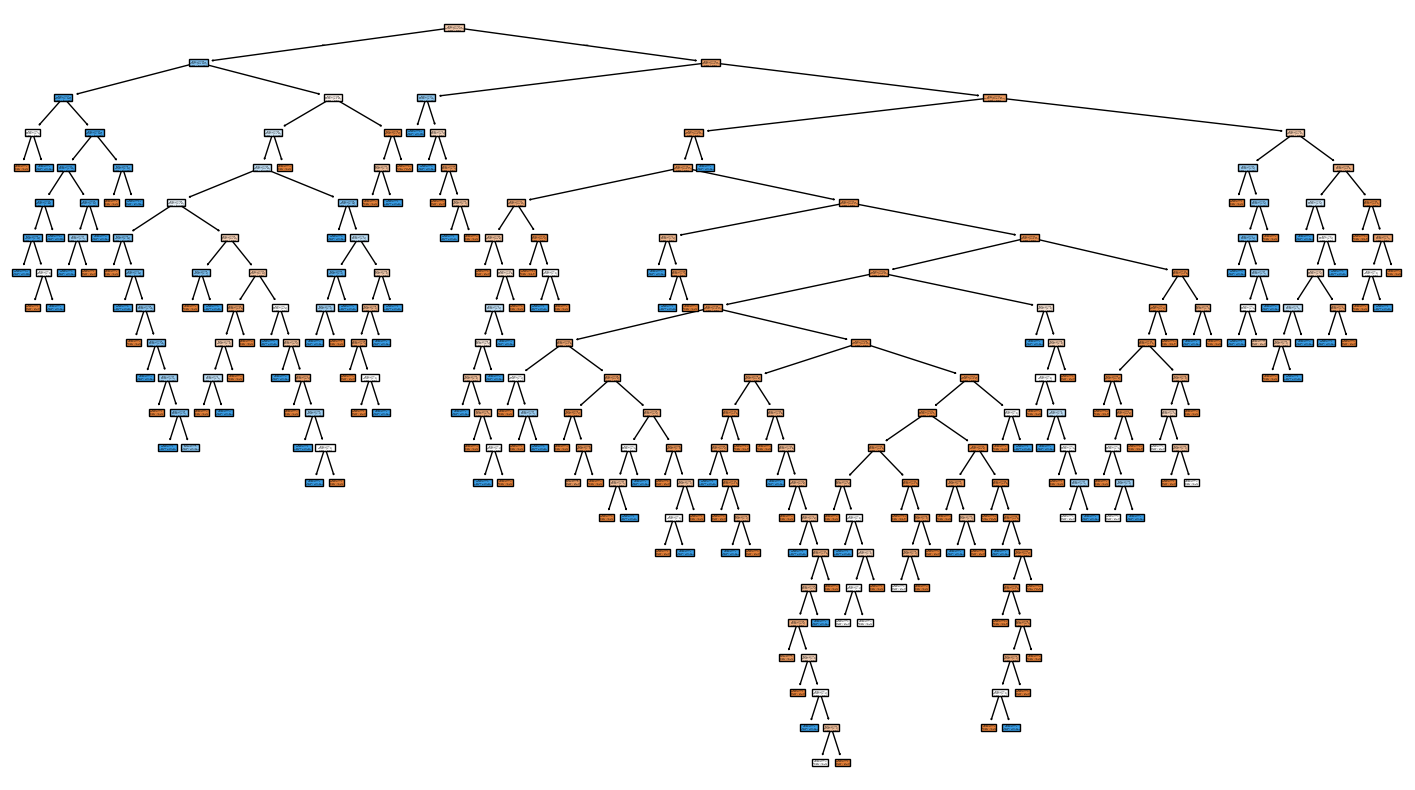

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled = True
)
plt.tight_layout
plt.show()

# Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=401,
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score:", rf.oob_score_ * 100, "%")  
print("testing accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

OOB score: 81.2199036918138 %
testing accuracy: 77.61194029850746 %


# Bagging classifier 

In [6]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train) 

y_pred = bagging.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))

accuracy: 0.7723880597014925


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# base model
base_model = DecisionTreeClassifier()

# bagging model
bagging = BaggingClassifier(
    estimator=base_model,
    n_estimators=201,
    random_state=42
)

# train model
bagging.fit(X_train, y_train)

# prediction
y_pred = bagging.predict(X_test)

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7686567164179104


# Regression 

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression

In [11]:
#generate data

X, y = make_regression(
    n_samples=1000,
    n_features=10,
    noise=20,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
X_train

array([[-1.02123282, -0.55519953,  0.24380071, ..., -2.19880596,
        -0.50205422,  0.44001445],
       [ 1.00730436, -1.75550559, -0.86442671, ..., -0.62483462,
         0.73215123, -1.10128649],
       [ 0.19091652, -0.47579544,  0.1469353 , ..., -1.35055596,
        -1.68466758, -0.07587145],
       ...,
       [ 2.57199532, -1.24224653,  0.60873559, ..., -0.06787138,
         0.73967547,  0.43163163],
       [ 0.03408347, -0.37912774,  0.23378591, ..., -1.01475673,
        -1.22394027, -0.64927755],
       [-0.32307574,  1.42395385,  0.97520054, ...,  0.13931963,
        -1.50080202,  1.11091114]], shape=(800, 10))

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

In [15]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

In [16]:
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [18]:
y_pred = gbr.predict(X_test)
print("r^2: ", r2_score(y_test, y_pred))

r^2:  0.9178283453526048


# Classifier

In [19]:
from sklearn.datasets import make_classification

In [22]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# create dataset
X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42
)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

In [25]:
gbc = GradientBoostingClassifier(
    learning_rate=0.1, 
    n_estimators=150, 
    max_depth=3,
    random_state=42
)

In [26]:
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
from sklearn.metrics import accuracy_score
y_pred = gbc.predict(X_test)
print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.9
